<a href="https://colab.research.google.com/github/caroline-2204/AIWIDS_TEAM-21/blob/feature-engineering/ai-wids-complete/notebooks/Krack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
try:
  from google.colab import drive
  drive.mount('/content/drive')
  os.chdir("/content/drive/MyDrive/COMP530-Project")
except ImportError:
  os.chdir("../data/processed")

Mounted at /content/drive


In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
import pandas as pd
df = pd.read_csv(
    "AWID3_Parsed/Krack.csv",
    escapechar='\\',
    low_memory=False,
    skiprows=range(1, 700000),
    # nrows=700000
    )

In [ ]:
desc_df = df.describe().T
filtered_df = desc_df[
    (desc_df['count'] >= 300000.0) &
    (desc_df['std'] > 0)
     ]
sorted_df = filtered_df.sort_values(by='std')
display(sorted_df)

,count,mean,std,min,25%,50%,75%,max
frame.time_delta_displayed,738494.0,4.315455e-04,5.360572e-03,0.000000e+00,3.000000e-06,2.900000e-05,1.790000e-04,3.323003e+00
frame.time_delta,738494.0,4.315455e-04,5.360572e-03,0.000000e+00,3.000000e-06,2.900000e-05,1.790000e-04,3.323003e+00
wlan.fc.type,738494.0,1.550033e+00,5.366397e-01,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
wlan_radio.phy,738494.0,6.560166e+00,9.040329e-01,4.000000e+00,6.000000e+00,7.000000e+00,7.000000e+00,8.000000e+00
wlan.fc.subtype,738494.0,9.121944e+00,1.761657e+00,0.000000e+00,8.000000e+00,8.000000e+00,1.100000e+01,1.400000e+01
radiotap.length,738494.0,5.682109e+01,2.684124e+00,4.800000e+01,5.600000e+01,5.600000e+01,5.600000e+01,6.400000e+01
wlan_radio.channel,738494.0,1.225539e+01,2.763381e+00,2.000000e+00,1.300000e+01,1.300000e+01,1.300000e+01,1.300000e+01
wlan_radio.signal_dbm,738494.0,-4.415088e+01,1.252455e+01,-9.100000e+01,-5.600000e+01,-3.500000e+01,-3.200000e+01,-2.600000e+01
wlan_radio.frequency,738494.0,2.468277e+03,1.381691e+01,2.417000e+03,2.472000e+03,2.472000e+03,2.472000e+03,2.472000e+03
radiotap.channel.freq,738494.0,2.468277e+03,1.381691e+01,2.417000e+03,2.472000e+03,2.472000e+03,2.472000e+03,2.472000e+03


In [ ]:
import numpy as np

condition = (
    (df['wlan_radio.channel'] == 2)
)

df['label'] = np.where(condition, 'krack', 'normal')

# Display the count of each label to verify
display(df['label'].value_counts())

,count
label,
normal,688504
krack,49990


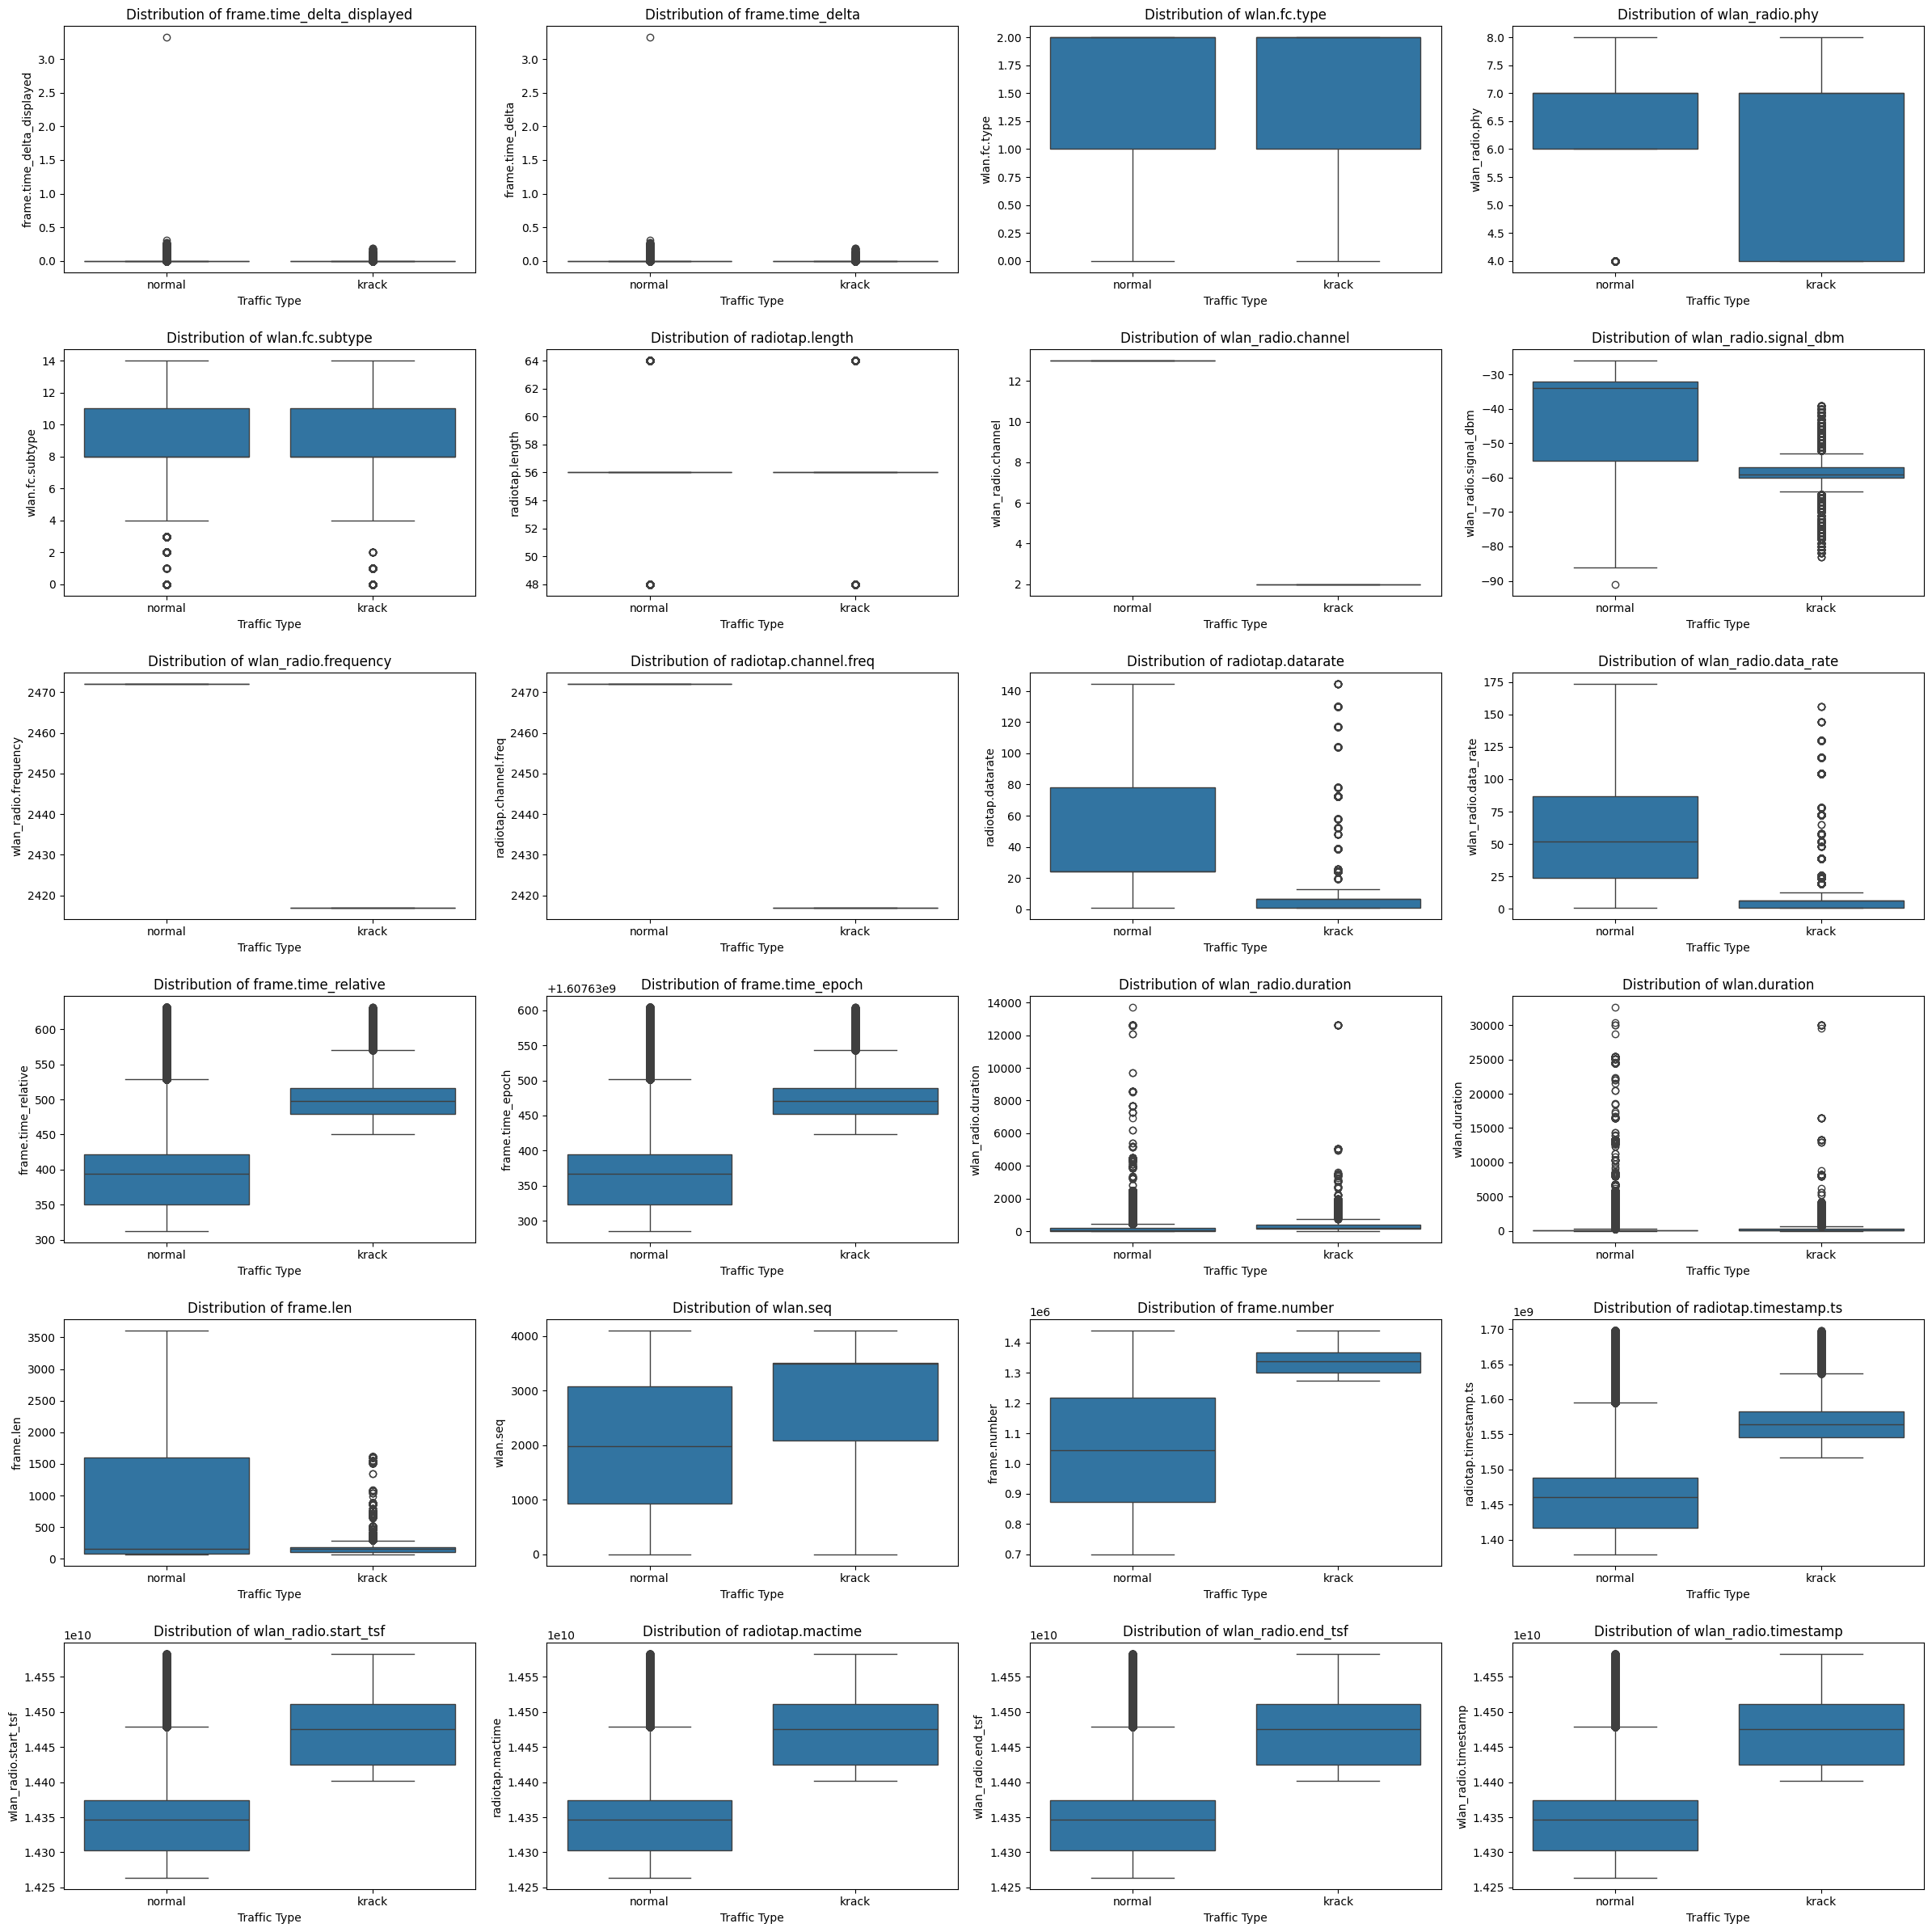

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of columns to plot from the index of sorted_df
columns_to_plot = sorted_df.index.tolist()

# Determine grid dimensions for subplots
num_columns = len(columns_to_plot)
num_cols_grid = 4  # Adjust as needed
num_rows_grid = (num_columns + num_cols_grid - 1) // num_cols_grid

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(num_cols_grid * 6, num_rows_grid * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(columns_to_plot):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Traffic Type')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()